=== 1. Create a Random Dataset ===
Dataset shape: (300, 2)
Train size: 225
Test size: 75
Classes: [0 1 2]


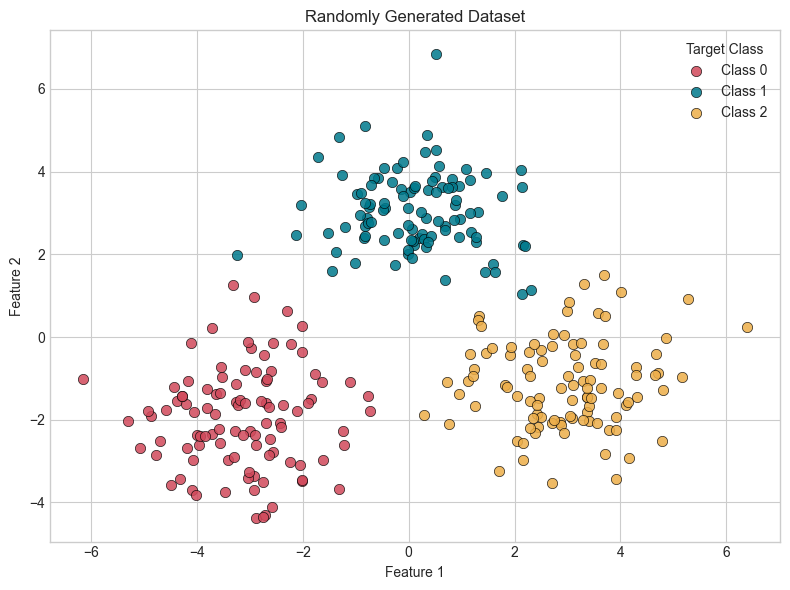


=== 2. Train a Decision Tree ===
Accuracy: 0.9733
Tree depth: 2
Number of leaves: 4

              precision    recall  f1-score   support

     Class 0       1.00      0.96      0.98        25
     Class 1       0.93      1.00      0.96        25
     Class 2       1.00      0.96      0.98        25

    accuracy                           0.97        75
   macro avg       0.98      0.97      0.97        75
weighted avg       0.98      0.97      0.97        75



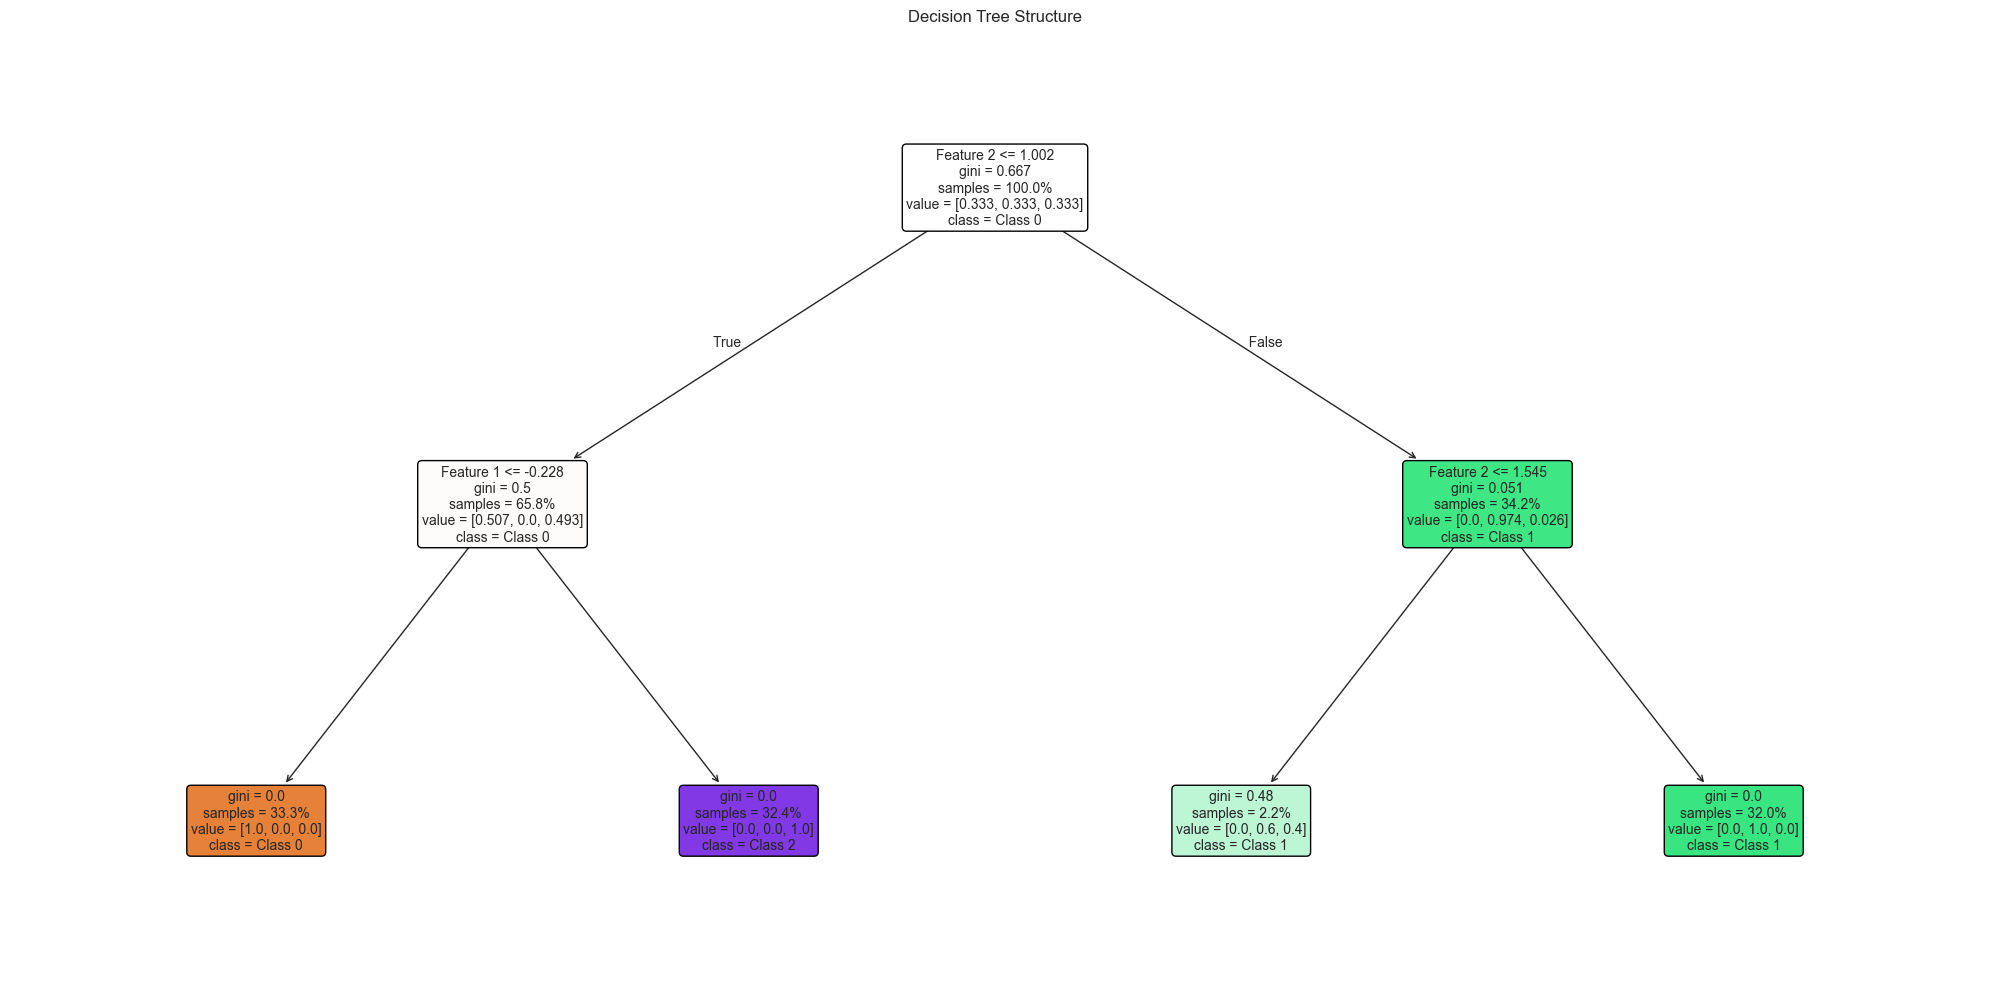

Decision Tree Rules
|--- Feature 2 <= 1.00
|   |--- Feature 1 <= -0.23
|   |   |--- class: 0
|   |--- Feature 1 >  -0.23
|   |   |--- class: 2
|--- Feature 2 >  1.00
|   |--- Feature 2 <= 1.55
|   |   |--- class: 1
|   |--- Feature 2 >  1.55
|   |   |--- class: 1


=== 3. Visualize How the Splits Work ===


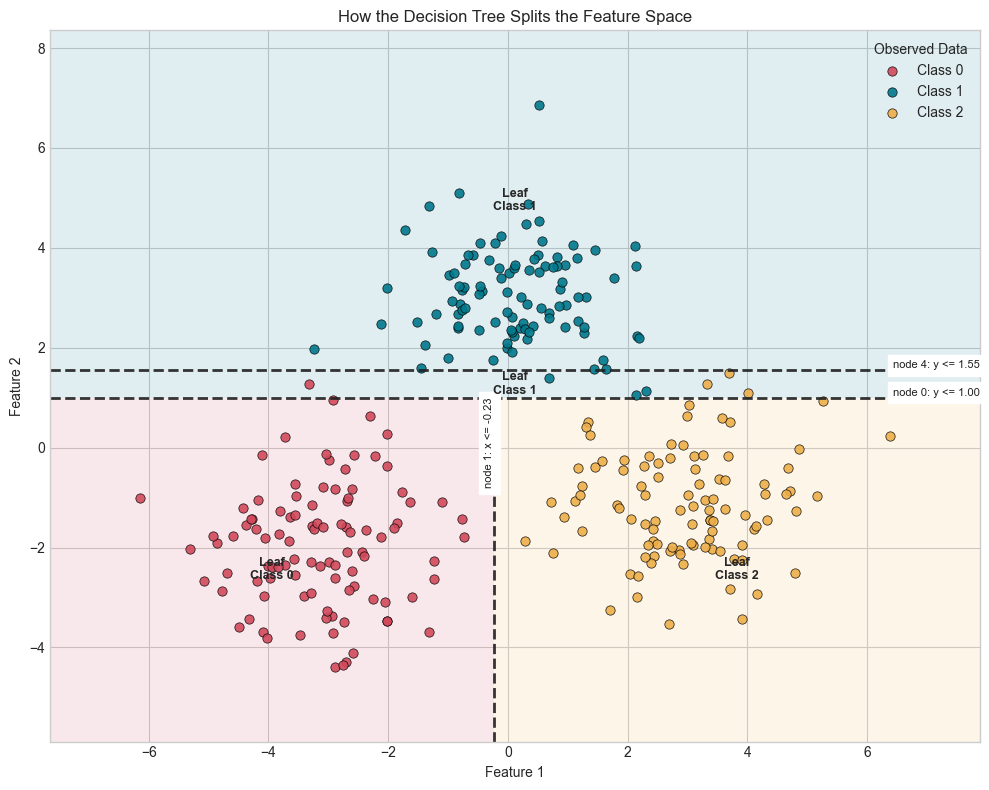


=== 4. Split Regions as Tree Depth Increases ===


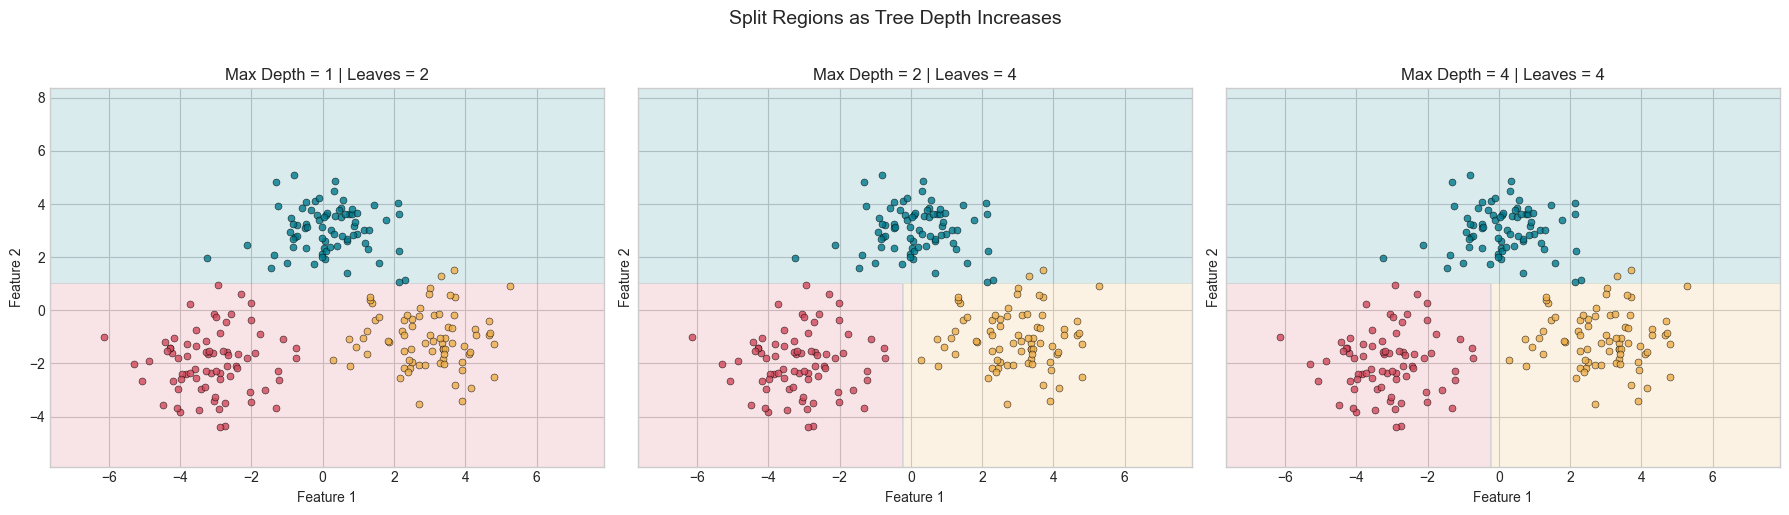


=== 5. Confusion Matrix ===


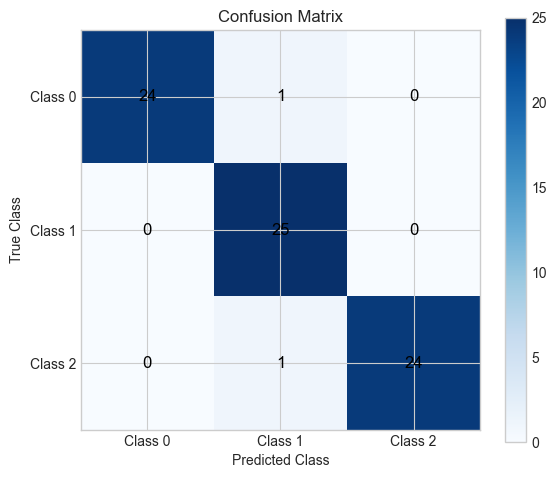

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

np.random.seed(42)
plt.style.use('seaborn-v0_8-whitegrid')

print('=== 1. Create a Random Dataset ===')
X, y = make_blobs(
    n_samples=300,
    centers=[(-3, -2), (0, 3), (3, -1)],
    cluster_std=[1.2, 1.0, 1.1],
    random_state=42,
)

feature_names = ['Feature 1', 'Feature 2']
class_names = ['Class 0', 'Class 1', 'Class 2']
colors = ['#d1495b', '#00798c', '#edae49']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

print(f'Dataset shape: {X.shape}')
print(f'Train size: {X_train.shape[0]}')
print(f'Test size: {X_test.shape[0]}')
print(f'Classes: {np.unique(y)}')

fig, ax = plt.subplots(figsize=(8, 6))
for class_id, color, label in zip(range(3), colors, class_names):
    mask = y == class_id
    ax.scatter(
        X[mask, 0], X[mask, 1],
        s=55, c=color, label=label,
        edgecolor='black', linewidth=0.5, alpha=0.85,
    )
ax.set_title('Randomly Generated Dataset')
ax.set_xlabel(feature_names[0])
ax.set_ylabel(feature_names[1])
ax.legend(title='Target Class')
plt.tight_layout()
plt.show()

print('\n=== 2. Train a Decision Tree ===')
clf = DecisionTreeClassifier(max_depth=4, min_samples_leaf=5, random_state=42)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)
print(f'Accuracy: {accuracy_score(y_test, y_pred):.4f}')
print(f'Tree depth: {clf.get_depth()}')
print(f'Number of leaves: {clf.get_n_leaves()}')
print()
print(classification_report(y_test, y_pred, target_names=class_names))

fig, ax = plt.subplots(figsize=(20, 10))
plot_tree(
    clf,
    feature_names=feature_names,
    class_names=class_names,
    filled=True,
    rounded=True,
    impurity=True,
    proportion=True,
    fontsize=10,
    ax=ax,
)
ax.set_title('Decision Tree Structure')
plt.tight_layout()
plt.show()

print('Decision Tree Rules')
print('=' * 60)
print(export_text(clf, feature_names=feature_names))

print('\n=== 3. Visualize How the Splits Work ===')

def get_class_color(class_id):
    return colors[class_id % len(colors)]


def plot_split_regions(ax, tree, node_id, x_min, x_max, y_min, y_max):
    is_leaf = tree.children_left[node_id] == tree.children_right[node_id]
    predicted_class = int(np.argmax(tree.value[node_id][0]))

    if is_leaf:
        region = Rectangle(
            (x_min, y_min),
            x_max - x_min,
            y_max - y_min,
            facecolor=get_class_color(predicted_class),
            alpha=0.12,
            edgecolor='none',
        )
        ax.add_patch(region)
        ax.text(
            (x_min + x_max) / 2,
            (y_min + y_max) / 2,
            f'Leaf\nClass {predicted_class}',
            ha='center',
            va='center',
            fontsize=9,
            weight='bold',
        )
        return

    feature_index = tree.feature[node_id]
    threshold = tree.threshold[node_id]
    line_color = '#1f1f1f'

    if feature_index == 0:
        ax.plot([threshold, threshold], [y_min, y_max], color=line_color, linestyle='--', linewidth=2, alpha=0.9)
        ax.text(
            threshold,
            y_max,
            f'node {node_id}: x <= {threshold:.2f}',
            rotation=90,
            ha='right',
            va='top',
            fontsize=8,
            color=line_color,
            backgroundcolor='white',
        )
        plot_split_regions(ax, tree, tree.children_left[node_id], x_min, threshold, y_min, y_max)
        plot_split_regions(ax, tree, tree.children_right[node_id], threshold, x_max, y_min, y_max)
    else:
        ax.plot([x_min, x_max], [threshold, threshold], color=line_color, linestyle='--', linewidth=2, alpha=0.9)
        ax.text(
            x_max,
            threshold,
            f'node {node_id}: y <= {threshold:.2f}',
            ha='right',
            va='bottom',
            fontsize=8,
            color=line_color,
            backgroundcolor='white',
        )
        plot_split_regions(ax, tree, tree.children_left[node_id], x_min, x_max, y_min, threshold)
        plot_split_regions(ax, tree, tree.children_right[node_id], x_min, x_max, threshold, y_max)


x_min, x_max = X[:, 0].min() - 1.5, X[:, 0].max() + 1.5
y_min, y_max = X[:, 1].min() - 1.5, X[:, 1].max() + 1.5

fig, ax = plt.subplots(figsize=(10, 8))
plot_split_regions(ax, clf.tree_, 0, x_min, x_max, y_min, y_max)

for class_id, color, label in zip(range(3), colors, class_names):
    mask = y == class_id
    ax.scatter(
        X[mask, 0], X[mask, 1],
        s=45, c=color, label=label,
        edgecolor='black', linewidth=0.5, alpha=0.9,
    )

ax.set_xlim(x_min, x_max)
ax.set_ylim(y_min, y_max)
ax.set_title('How the Decision Tree Splits the Feature Space')
ax.set_xlabel(feature_names[0])
ax.set_ylabel(feature_names[1])
ax.legend(title='Observed Data')
plt.tight_layout()
plt.show()

print('\n=== 4. Split Regions as Tree Depth Increases ===')
depths = [1, 2, 4]
fig, axes = plt.subplots(1, len(depths), figsize=(18, 5), sharex=True, sharey=True)

for ax, depth in zip(axes, depths):
    model = DecisionTreeClassifier(max_depth=depth, min_samples_leaf=5, random_state=42)
    model.fit(X_train, y_train)

    grid_x = np.linspace(x_min, x_max, 400)
    grid_y = np.linspace(y_min, y_max, 400)
    xx, yy = np.meshgrid(grid_x, grid_y)
    predictions = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

    ax.contourf(xx, yy, predictions, alpha=0.15, levels=np.arange(-0.5, 3.5, 1), colors=colors)

    for class_id, color in enumerate(colors):
        mask = y_train == class_id
        ax.scatter(
            X_train[mask, 0], X_train[mask, 1],
            s=25, c=color, edgecolor='black', linewidth=0.4, alpha=0.8,
        )

    ax.set_title(f'Max Depth = {depth} | Leaves = {model.get_n_leaves()}')
    ax.set_xlabel(feature_names[0])
    ax.set_ylabel(feature_names[1])

plt.suptitle('Split Regions as Tree Depth Increases', y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

print('\n=== 5. Confusion Matrix ===')
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, cmap='Blues')
plt.colorbar(im, ax=ax)

ax.set_xticks(np.arange(len(class_names)))
ax.set_yticks(np.arange(len(class_names)))
ax.set_xticklabels(class_names)
ax.set_yticklabels(class_names)
ax.set_xlabel('Predicted Class')
ax.set_ylabel('True Class')
ax.set_title('Confusion Matrix')

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, cm[i, j], ha='center', va='center', color='black', fontsize=12)

plt.tight_layout()
plt.show()
